# Lab 1 - Intro to Behavioral TV Data
Name: Oleksandr Serpovych Liubomyrovych | Group: KM-41

## Setup

In [10]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA = kagglehub.dataset_download("shkarupylomaxim/adtech-lab1-tv-panel/versions/2")

programs = pd.read_parquet(f"{DATA}/programs.parquet")
viewings = pd.read_parquet(f"{DATA}/viewings.parquet")
daily_weights = pd.read_parquet(f"{DATA}/daily_weights.parquet")
viewer_attributes = pd.read_parquet(f"{DATA}/viewer_attributes.parquet")
attributes = pd.read_parquet(f"{DATA}/attributes.parquet")

## Task 1.1 — Panel and universe    

In [11]:
# Calculating unique values for programs
telecasts = programs['telecast_id'].nunique()
distinct_programs = programs['program_name'].nunique()
networks = programs['network_code'].nunique()

# Filtering in-tab respondents (only those who were surveyed at least once)
hh_in_tab = daily_weights[daily_weights['resp_type'] == 'H']['respondent_id'].nunique()
persons_in_tab = daily_weights[daily_weights['resp_type'].isin(['R', 'L'])]['respondent_id'].nunique()

# Calculation of daily averages
daily_stats = daily_weights.groupby(['broadcast_date', 'resp_type']).agg(
    in_tab_count=('respondent_id', 'count'),
    projected_sum=('weight', 'sum')
).unstack('resp_type')

avg_hh_in_tab = daily_stats['in_tab_count']['H'].mean()
avg_persons_in_tab = daily_stats['in_tab_count'][['R', 'L']].sum(axis=1).mean()
avg_hh_proj = daily_stats['projected_sum']['H'].mean() / 1e6
avg_persons_proj = daily_stats['projected_sum'][['R', 'L']].sum(axis=1).mean() / 1e6

print(f"Telecasts: {telecasts}")
print(f"Programs: {distinct_programs}")
print(f"Networks: {networks}")
print(f"Households in panel: {hh_in_tab}")
print(f"Persons in panel: {persons_in_tab}")
print(f"Households in-tab, average day: {int(avg_hh_in_tab)}")
print(f"Persons in-tab, average day: {int(avg_persons_in_tab)}")
print(f"US TV households represented, average day (M): {avg_hh_proj:.2f}")
print(f"US persons represented, average day (M): {avg_persons_proj:.2f}")

Telecasts: 5841
Programs: 246
Networks: 10
Households in panel: 4254
Persons in panel: 10210
Households in-tab, average day: 3878
Persons in-tab, average day: 9268
US TV households represented, average day (M): 125.80
US persons represented, average day (M): 317.28


## Task 1.2 — Average audience by hour of day

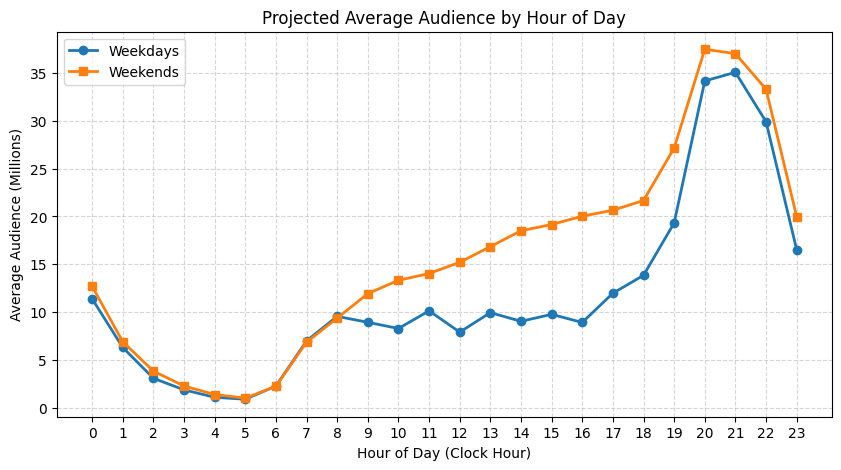

Peak hour, weekdays: 21
Peak hour, weekends: 20


In [12]:
# Including only views by permanent residents (R) and long-term guests (L)
# Excluding guests (S) in accordance with the laboratory rules
person_viewings = viewings[viewings['resp_type'].isin(['R', 'L'])].copy()

# Rounding timestamps down to the top of the hour
person_viewings['start_hr'] = person_viewings['start_ts'].dt.floor('h')
person_viewings['end_hr'] = person_viewings['end_ts'].dt.floor('h')

# Determining how many hourly boundaries each session crosses
person_viewings['hour_diff'] = ((person_viewings['end_hr'] - person_viewings['start_hr']).dt.total_seconds() / 3600).astype(int)

# Multiplying the sessions by the number of hours involved
expanded = person_viewings.loc[person_viewings.index.repeat(person_viewings['hour_diff'] + 1)].copy()
expanded['step'] = expanded.groupby(level=0).cumcount()
expanded['current_hour'] = expanded['start_hr'] + pd.to_timedelta(expanded['step'], unit='h')

# Calculating the exact time interval for each hour [current_hour, next_hour]
expanded['next_hour'] = expanded['current_hour'] + pd.Timedelta(hours=1)
expanded['piece_start'] = expanded[['start_ts', 'current_hour']].max(axis=1)
expanded['piece_end'] = expanded[['end_ts', 'next_hour']].min(axis=1)

# Duration in minutes within that specific hour
expanded['duration_min'] = (expanded['piece_end'] - expanded['piece_start']).dt.total_seconds() / 60
# Excluding zero intersections (if the session ended exactly at 00 minutes)
expanded = expanded[expanded['duration_min'] > 0].copy()

# Determining the broadcast date (Broadcast Date: shifted back by 6 hours)
# As a result, 1:00 a.m. on Friday will be correctly assigned to Thursday
expanded['b_date'] = (expanded['current_hour'] - pd.Timedelta(hours=6)).dt.date
expanded['b_date'] = pd.to_datetime(expanded['b_date'])
expanded['is_weekend'] = expanded['b_date'].dt.dayofweek >= 5

# Weighted viewing time
expanded['weighted_min'] = expanded['duration_min'] * expanded['weight']
expanded['clock_hour'] = expanded['current_hour'].dt.hour

# Number of unique weekday and weekend broadcast days in October
all_b_dates = pd.to_datetime(daily_weights['broadcast_date']).drop_duplicates()
num_weekends = (all_b_dates.dt.dayofweek >= 5).sum()
num_weekdays = (all_b_dates.dt.dayofweek < 5).sum()

# Aggregation of weighted minutes by hour (0–23)
hourly_agg = expanded.groupby(['is_weekend', 'clock_hour'])['weighted_min'].sum().reset_index()

hourly_agg.loc[~hourly_agg['is_weekend'], 'avg_aud_m'] = (
    hourly_agg.loc[~hourly_agg['is_weekend'], 'weighted_min'] / 60 / num_weekdays / 1e6
)
hourly_agg.loc[hourly_agg['is_weekend'], 'avg_aud_m'] = (
    hourly_agg.loc[hourly_agg['is_weekend'], 'weighted_min'] / 60 / num_weekends / 1e6
)

wd_stats = hourly_agg[~hourly_agg['is_weekend']].sort_values('clock_hour')
we_stats = hourly_agg[hourly_agg['is_weekend']].sort_values('clock_hour')

# Plotting a graph
plt.figure(figsize=(10, 5))
plt.plot(wd_stats['clock_hour'], wd_stats['avg_aud_m'], label='Weekdays', marker='o', linewidth=2)
plt.plot(we_stats['clock_hour'], we_stats['avg_aud_m'], label='Weekends', marker='s', linewidth=2)
plt.title('Projected Average Audience by Hour of Day')
plt.xlabel('Hour of Day (Clock Hour)')
plt.ylabel('Average Audience (Millions)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

peak_wd = int(wd_stats.loc[wd_stats['avg_aud_m'].idxmax()]['clock_hour'])
peak_we = int(we_stats.loc[we_stats['avg_aud_m'].idxmax()]['clock_hour'])

print(f"Peak hour, weekdays: {peak_wd}")
print(f"Peak hour, weekends: {peak_we}")

**Answer:** On weekends, daytime viewing is substantially higher, steadily climbing to 13–21M viewers between 10:00 and 18:00 (compared to only 8–14M on weekdays). The weekend peak also shifts one hour earlier and slightly higher, reaching ~37.5M at hour 20 compared to ~35.1M at hour 21 on weekdays.

## Task 1.3 — Session lenght

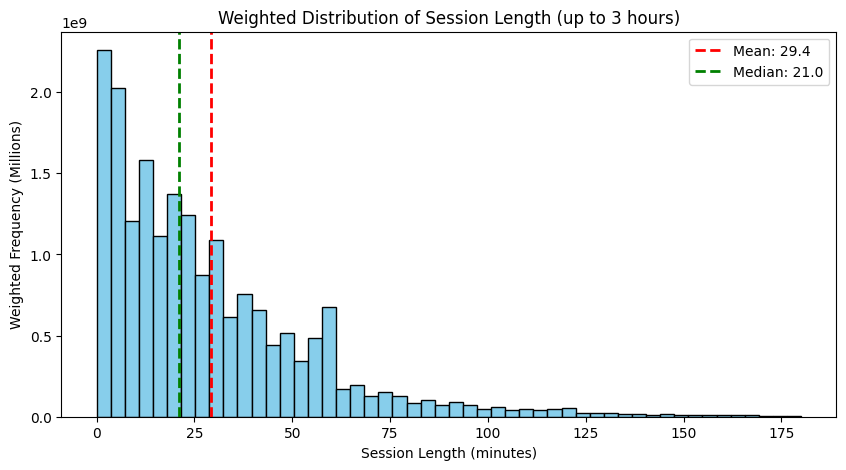

Session length, weighted mean (min): 29.4
Session length, weighted median (min): 21.0


In [13]:
# Returning to the original sessions
person_viewings['session_length'] = (person_viewings['end_ts'] - person_viewings['start_ts']).dt.total_seconds() / 60

weighted_mean = (person_viewings['session_length'] * person_viewings['weight']).sum() / person_viewings['weight'].sum()

# Weighted median
sorted_views = person_viewings.sort_values('session_length')
sorted_views['cum_weight'] = sorted_views['weight'].cumsum()
total_weight = sorted_views['weight'].sum()
weighted_median = sorted_views[sorted_views['cum_weight'] >= total_weight / 2]['session_length'].iloc[0]

# Constructing a distribution
plt.figure(figsize=(10, 5))
plt.hist(person_viewings['session_length'], bins=50, weights=person_viewings['weight'], range=(0, 180), color='skyblue', edgecolor='black')
plt.title('Weighted Distribution of Session Length (up to 3 hours)')
plt.xlabel('Session Length (minutes)')
plt.ylabel('Weighted Frequency (Millions)')
plt.axvline(weighted_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {weighted_mean:.1f}')
plt.axvline(weighted_median, color='green', linestyle='dashed', linewidth=2, label=f'Median: {weighted_median:.1f}')
plt.legend()
plt.show()

print(f"Session length, weighted mean (min): {weighted_mean:.1f}")
print(f"Session length, weighted median (min): {weighted_median:.1f}")

**Answer:** The weighted mean (29.4 min) is noticeably higher than the weighted median (21.0 min) due to a heavy right tail caused by a small number of very long continuous sessions. I would include the median (21.0 min) in a client deck because "the average can lie," whereas the median serves as a robust metric of typical viewer engagement that is unaffected by extreme outliers.

## Task 2 — Program reach curve

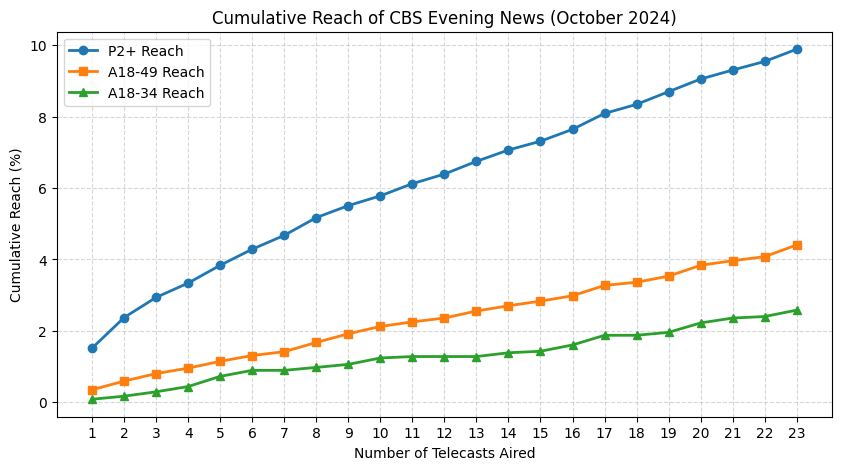

Telecasts of the program: 23
Average household rating (%): 3.2
Average P2+ rating (%): 1.6
Average projected audience (M): 4.93
Final reach P2+ (%): 9.9
Final reach A18-34 (%): 2.6
Final reach A18-49 (%): 4.4


In [14]:
# Compiling all the “CBS Evening News” broadcasts from October in the correct order (by time)
cbs_news = programs[(programs['network_code'] == 'CBS') & 
                    (programs['program_name'] == 'CBS Evening News')].sort_values('start_ts').copy()

# Tracking all views on the CBS channel
cbs_views = viewings[viewings['network_code'] == 'CBS'].copy()

# Using a Cross Join to find the intersections between views and news broadcasts
cbs_news['dummy'] = 1
cbs_views['dummy'] = 1
merged = pd.merge(cbs_views, cbs_news[['telecast_id', 'start_ts', 'end_ts', 'broadcast_date', 'dummy']], 
                  on='dummy', suffixes=('_v', '_p'))

# Calculating the time when the intervals overlap: [max(start1, start2), min(end1, end2)]
merged['intersect_start'] = merged[['start_ts_v', 'start_ts_p']].max(axis=1)
merged['intersect_end'] = merged[['end_ts_v', 'end_ts_p']].min(axis=1)
merged['duration'] = (merged['intersect_end'] - merged['intersect_start']).dt.total_seconds() / 60

# Keeping only the views that lasted at least 1 minute
watched = merged[merged['duration'] >= 1.0].copy()

# Demographics: Retrieving age (code 300) from viewer_attributes
ages = viewer_attributes[viewer_attributes['attr_id'] == 300][['respondent_id', 'value']].rename(columns={'value': 'age'})

# Preparation of the general population (Universe) for each day
dw = daily_weights.merge(ages, on='respondent_id', how='left')
dw['is_H'] = dw['resp_type'] == 'H'
dw['is_P2'] = dw['resp_type'].isin(['R', 'L'])
dw['is_A18_34'] = dw['is_P2'] & dw['age'].between(18, 34)
dw['is_A18_49'] = dw['is_P2'] & dw['age'].between(18, 49)

# Preparing “monthly” weights for calculating reach
avg_weights_df = dw.groupby('respondent_id')['weight'].mean().reset_index()
avg_weights_df = avg_weights_df.merge(dw[['respondent_id', 'is_P2', 'is_A18_34', 'is_A18_49']].drop_duplicates(), on='respondent_id')

univ_reach_P2 = avg_weights_df[avg_weights_df['is_P2']]['weight'].sum()
univ_reach_A18_34 = avg_weights_df[avg_weights_df['is_A18_34']]['weight'].sum()
univ_reach_A18_49 = avg_weights_df[avg_weights_df['is_A18_49']]['weight'].sum()

avg_weights_series = avg_weights_df.set_index('respondent_id')['weight']

# Adding demographic flags to our view facts table
watched = watched.merge(ages, on='respondent_id', how='left')
watched['is_H'] = watched['resp_type'] == 'H'
watched['is_P2'] = watched['resp_type'].isin(['R', 'L'])
watched['is_A18_34'] = watched['is_P2'] & watched['age'].between(18, 34)
watched['is_A18_49'] = watched['is_P2'] & watched['age'].between(18, 49)

# Iterative calculation of ratings and audience growth for each broadcast
results = []
cum_viewers = {'P2': set(), 'A18_34': set(), 'A18_49': set()}
reach_curves = {'P2': [], 'A18_34': [], 'A18_49': []}

for idx, row in cbs_news.iterrows():
    tid = row['telecast_id']
    b_date = row['broadcast_date']
    
    # General population for a specific day for the ranking
    dw_day = dw[dw['broadcast_date'] == b_date]
    univ_H = dw_day[dw_day['is_H']]['weight'].sum()
    univ_P2 = dw_day[dw_day['is_P2']]['weight'].sum()
    
    # Unique viewers of a specific broadcast
    w_tel = watched[watched['telecast_id'] == tid].drop_duplicates(subset=['respondent_id'])
    
    # Sum of the audience weights
    w_H = w_tel[w_tel['is_H']]['weight'].sum()
    w_P2 = w_tel[w_tel['is_P2']]['weight'].sum()
    
    # Calculating ratings and audience
    rating_H = (w_H / univ_H * 100) if univ_H > 0 else 0
    rating_P2 = (w_P2 / univ_P2 * 100) if univ_P2 > 0 else 0
    proj_aud = w_P2 / 1_000_000
    results.append({'telecast_id': tid, 'rating_H': rating_H, 'rating_P2': rating_P2, 'proj_aud_M': proj_aud})
    
    # Updating unique viewer sets for cumulative reach
    cum_viewers['P2'].update(w_tel[w_tel['is_P2']]['respondent_id'].tolist())
    cum_viewers['A18_34'].update(w_tel[w_tel['is_A18_34']]['respondent_id'].tolist())
    cum_viewers['A18_49'].update(w_tel[w_tel['is_A18_49']]['respondent_id'].tolist())
    
    # Calculating the coverage percentage based on monthly weights
    r_P2 = avg_weights_series.loc[list(cum_viewers['P2'])].sum() / univ_reach_P2 * 100 if cum_viewers['P2'] else 0
    r_A18_34 = avg_weights_series.loc[list(cum_viewers['A18_34'])].sum() / univ_reach_A18_34 * 100 if cum_viewers['A18_34'] else 0
    r_A18_49 = avg_weights_series.loc[list(cum_viewers['A18_49'])].sum() / univ_reach_A18_49 * 100 if cum_viewers['A18_49'] else 0
    
    reach_curves['P2'].append(r_P2)
    reach_curves['A18_34'].append(r_A18_34)
    reach_curves['A18_49'].append(r_A18_49)

res_df = pd.DataFrame(results)

# Visualization of the coverage curve
plt.figure(figsize=(10, 5))
x_axis = range(1, len(cbs_news) + 1)
plt.plot(x_axis, reach_curves['P2'], label='P2+ Reach', marker='o', linewidth=2)
plt.plot(x_axis, reach_curves['A18_49'], label='A18-49 Reach', marker='s', linewidth=2)
plt.plot(x_axis, reach_curves['A18_34'], label='A18-34 Reach', marker='^', linewidth=2)
plt.title('Cumulative Reach of CBS Evening News (October 2024)')
plt.xlabel('Number of Telecasts Aired')
plt.ylabel('Cumulative Reach (%)')
plt.xticks(x_axis)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Output results
print(f"Telecasts of the program: {len(cbs_news)}")
print(f"Average household rating (%): {res_df['rating_H'].mean():.1f}")
print(f"Average P2+ rating (%): {res_df['rating_P2'].mean():.1f}")
print(f"Average projected audience (M): {res_df['proj_aud_M'].mean():.2f}")
print(f"Final reach P2+ (%): {reach_curves['P2'][-1]:.1f}")
print(f"Final reach A18-34 (%): {reach_curves['A18_34'][-1]:.1f}")
print(f"Final reach A18-49 (%): {reach_curves['A18_49'][-1]:.1f}")

**Answer:** Cumulative reach keeps growing to 9.9% (P2+) despite a flat average telecast rating of only 1.6% because different people tune in on different days, gradually accumulating a larger unique audience over 23 telecasts. The program reaches the general P2+ audience (9.9%) much better than younger demographics like A18-49 (4.4%) or A18-34 (2.6%), which perfectly aligns with the traditionally older viewership of network evening news.

## Task 3 — Program frequency

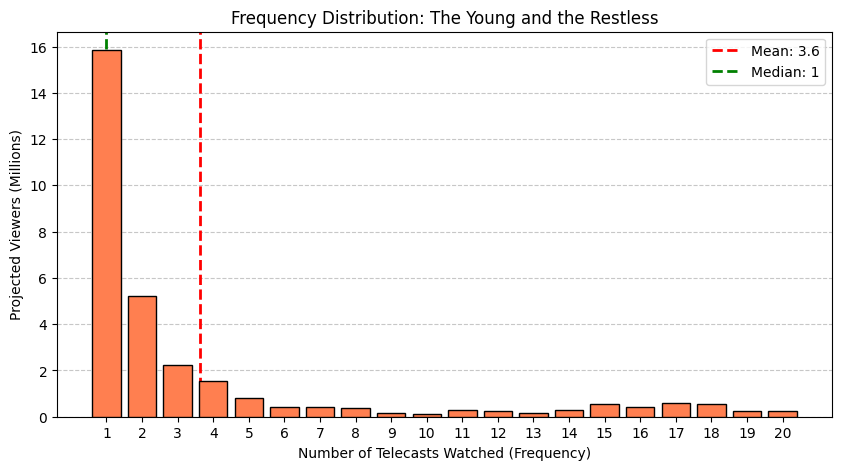

Projected viewers (M): 30.80
Average frequency (weighted): 3.6
Median frequency (weighted): 1
Share of views from the most loyal viewers: 0.704


In [15]:
# Featuring all episodes of “The Young and the Restless” on CBS
soap_programs = programs[(programs['network_code'] == 'CBS') & 
                         (programs['program_name'] == 'The Young and the Restless')].copy()

# Selecting CBS viewership among individuals (P2+: types R and L)
cbs_views = viewings[(viewings['network_code'] == 'CBS') & 
                     (viewings['resp_type'].isin(['R', 'L']))].copy()

# Cross Join for finding intersections
soap_programs['dummy'] = 1
cbs_views['dummy'] = 1
merged_soap = pd.merge(cbs_views, soap_programs[['telecast_id', 'start_ts', 'end_ts', 'dummy']], 
                       on='dummy', suffixes=('_v', '_p'))

# Finding the time of intersection
merged_soap['intersect_start'] = merged_soap[['start_ts_v', 'start_ts_p']].max(axis=1)
merged_soap['intersect_end'] = merged_soap[['end_ts_v', 'end_ts_p']].min(axis=1)
merged_soap['duration'] = (merged_soap['intersect_end'] - merged_soap['intersect_start']).dt.total_seconds() / 60

# Counting a view if its duration is >= 1 min
watched_soap = merged_soap[merged_soap['duration'] >= 1.0].copy()

# Calculating the frequency for each respondent
user_freq = watched_soap.groupby('respondent_id')['telecast_id'].nunique().reset_index()
user_freq.rename(columns={'telecast_id': 'frequency'}, inplace=True)

# Calculating the “monthly weight” for each in-tab viewer
dw_persons = daily_weights[daily_weights['resp_type'].isin(['R', 'L'])]
monthly_weights = dw_persons.groupby('respondent_id')['weight'].mean().reset_index()

# Merging the calculated frequency by the monthly weight
freq_df = user_freq.merge(monthly_weights, on='respondent_id', how='inner')

# Calculating key metrics
projected_viewers = freq_df['weight'].sum() / 1_000_000

# Weighted average frequency: Sum (frequency * weight) / total weight
weighted_avg_freq = (freq_df['frequency'] * freq_df['weight']).sum() / freq_df['weight'].sum()

# Weighted median frequency
freq_df = freq_df.sort_values('frequency')
freq_df['cum_weight'] = freq_df['weight'].cumsum()
total_weight = freq_df['weight'].sum()
weighted_median_freq = freq_df[freq_df['cum_weight'] >= total_weight / 2]['frequency'].iloc[0]

# Loyalty analysis (80th percentile)
p80_freq = freq_df[freq_df['cum_weight'] >= total_weight * 0.8]['frequency'].iloc[0]
freq_df['is_loyal'] = freq_df['frequency'] >= p80_freq

# Number of views generated for each respondent = frequency * their weight
freq_df['projected_views'] = freq_df['frequency'] * freq_df['weight']

total_views = freq_df['projected_views'].sum()
loyal_views = freq_df[freq_df['is_loyal']]['projected_views'].sum()
share_loyal_views = loyal_views / total_views

# Plotting a frequency distribution graph
freq_dist = freq_df.groupby('frequency')['weight'].sum().reset_index()
freq_dist['viewers_M'] = freq_dist['weight'] / 1_000_000

plt.figure(figsize=(10, 5))
plt.bar(freq_dist['frequency'], freq_dist['viewers_M'], color='coral', edgecolor='black', zorder=3)
plt.title('Frequency Distribution: The Young and the Restless')
plt.xlabel('Number of Telecasts Watched (Frequency)')
plt.ylabel('Projected Viewers (Millions)')
plt.xticks(range(1, freq_dist['frequency'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.axvline(weighted_avg_freq, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {weighted_avg_freq:.1f}')
plt.axvline(weighted_median_freq, color='green', linestyle='dashed', linewidth=2, label=f'Median: {weighted_median_freq:.0f}')
plt.legend()
plt.show()

# Final results
print(f"Projected viewers (M): {projected_viewers:.2f}")
print(f"Average frequency (weighted): {weighted_avg_freq:.1f}")
print(f"Median frequency (weighted): {weighted_median_freq:.0f}")
print(f"Share of views from the most loyal viewers: {share_loyal_views:.3f}")

**Answer:** The most loyal viewers generate 70.4% of all projected views. The average frequency (3.6) is not a fair summary ("the average can lie") because the distribution is heavily right-skewed: the vast majority of people watched only 1 telecast (the median), while the average is artificially pulled up by a small group of highly dedicated viewers.

## Task 4 — Networks by age and gender

In [16]:
# Selecting individual observations (R and L) and excluding guests and households
p_viewings = viewings[viewings['resp_type'].isin(['R', 'L'])].copy()

# Counting the duration of each session and keeping only those that are >= 1 minute
p_viewings['duration'] = (p_viewings['end_ts'] - p_viewings['start_ts']).dt.total_seconds() / 60
p_viewings = p_viewings[p_viewings['duration'] >= 1.0].copy()

# Retrieving demographic data from viewer_attributes
# Age (code 300)
ages = viewer_attributes[viewer_attributes['attr_id'] == 300][['respondent_id', 'value']]
ages = ages.rename(columns={'value': 'age'})

# Gender (codes 201 - Men, 202 - Women)
genders = viewer_attributes[viewer_attributes['attr_id'].isin([201, 202])][['respondent_id', 'attr_id']]
genders['is_M'] = genders['attr_id'] == 201
genders['is_W'] = genders['attr_id'] == 202

# Merging views to demographics
df = p_viewings.merge(ages, on='respondent_id', how='inner')
df = df.merge(genders, on='respondent_id', how='inner')

# Counting the raw and weighed minutes
df['raw_min'] = df['duration']
df['proj_min'] = df['duration'] * df['weight']

# Creating boolean masks for all 6 target audiences
df['M18-34'] = df['is_M'] & df['age'].between(18, 34)
df['W18-34'] = df['is_W'] & df['age'].between(18, 34)
df['M35-54'] = df['is_M'] & df['age'].between(35, 54)
df['W35-54'] = df['is_W'] & df['age'].between(35, 54)
df['M55+']   = df['is_M'] & (df['age'] >= 55)
df['W55+']   = df['is_W'] & (df['age'] >= 55)
df['A18-34'] = df['age'].between(18, 34)

# Vector product of flags and weighted minutes
audiences = ['M18-34', 'W18-34', 'M35-54', 'W35-54', 'M55+', 'W55+']
for aud in audiences:
    df[f'{aud}_proj'] = df[aud] * df['proj_min']

df['A18-34_proj'] = df['A18-34'] * df['proj_min']
df['A18-34_raw']  = df['A18-34'] * df['raw_min']

# Aggregation of data by TV channel
agg_dict = {f'{aud}_proj': 'sum' for aud in audiences}
agg_dict.update({
    'proj_min': 'sum',
    'raw_min': 'sum',
    'A18-34_proj': 'sum',
    'A18-34_raw': 'sum'
})
net_stats = df.groupby('network_code').agg(agg_dict).reset_index()

# Output of the six Top 5 tables (in millions, to two decimal places)
print("--- TOP 5 NETWORKS BY AUDIENCE (Projected Minutes, Millions) ---")
for aud in audiences:
    col = f'{aud}_proj'
    top5 = net_stats[['network_code', col]].sort_values(col, ascending=False).head(5).copy()
    top5[col] = (top5[col] / 1e6).round(2)
    top5.rename(columns={col: f'{aud} Minutes (M)'}, inplace=True)
    
    print(f"\nTop 5 for {aud}:")
    display(top5.style.hide(axis='index'))

# Calculating the audience share for the 18–34 age group (Weighted vs. Raw)
net_stats['share_18_34_weighted'] = (net_stats['A18-34_proj'] / net_stats['proj_min']).round(3)
net_stats['share_18_34_raw'] = (net_stats['A18-34_raw'] / net_stats['raw_min']).round(3)

share_df = net_stats[['network_code', 'share_18_34_weighted', 'share_18_34_raw']].sort_values('share_18_34_weighted', ascending=False)

print("\n--- 18-34 SHARE OF MINUTES PER NETWORK ---")
display(share_df.style.hide(axis='index'))

# Identifying the youngest and oldest TV channels
youngest = share_df.loc[share_df['share_18_34_weighted'].idxmax(), 'network_code']
oldest = share_df.loc[share_df['share_18_34_weighted'].idxmin(), 'network_code']

print(f"\nYoungest network: {youngest}")
print(f"Oldest network: {oldest}")

--- TOP 5 NETWORKS BY AUDIENCE (Projected Minutes, Millions) ---

Top 5 for M18-34:


network_code,M18-34 Minutes (M)
FOX,4386.650000
NBC,3910.390000
CBS,3044.350000
ABC,3010.780000
FX,1473.960000



Top 5 for W18-34:


network_code,W18-34 Minutes (M)
FOX,4574.440000
NBC,4527.590000
ABC,3504.860000
CBS,2811.220000
FX,1383.470000



Top 5 for M35-54:


...


Top 5 for W55+:


network_code,W55+ Minutes (M)
CBS,47120.320000
NBC,41391.870000
ABC,38840.010000
FOX,36914.720000
FNC,31450.730000



--- 18-34 SHARE OF MINUTES PER NETWORK ---


network_code,share_18_34_weighted,share_18_34_raw
FX,0.266000,0.232000
BRAVO,0.148000,0.127000
FOX,0.082000,0.075000
FOOD,0.078000,0.071000
NBC,0.073000,0.068000
ABC,0.064000,0.060000
HGTV,0.058000,0.052000
CBS,0.051000,0.050000
HIST,0.048000,0.044000
FNC,0.018000,0.017000



Youngest network: FX
Oldest network: FNC


**Answer:** The weighted share of 18-34 viewers is consistently higher than the raw share across networks (e.g., FX is 26.6% weighted vs. 23.2% raw), which indicates that young adults are under-represented in the physical TV panel. If I reported raw numbers to a client, I would severely underestimate the actual size of the young audience, misleading the advertiser about the campaign's demographic delivery.

**Bonus answer:** If I were pitching FNC (the oldest network) to an advertiser targeting young adults, I would position it as a highly cost-efficient source of incremental reach: since 18-34 is not FNC's core demographic, the CPM for this specific audience is likely very low, allowing the brand to cheaply reach unique, unduplicated young viewers who might be co-viewing with their older relatives.